# Mazdas: five-class baby-cry intermediate fusion

This notebook contains the complete preparation, training, validation, test evaluation,
and prediction workflow. No external Python scripts are needed. Keep this notebook
beside the five dataset folders (`eairh`, `eh`, `heh`, `neh`, `owh`) and `results/`.

**Recorded result:** ResNet18 + mean pooling achieved **81.25% test accuracy (26/32)**
and **0.7578 test macro F1**. Attention is a validation comparison, not a second test
selection attempt. These are dataset-label predictions, not medical diagnoses.

**Run All defaults to reviewing the supplied results**, with no retraining or new test
evaluation. Change the switches below to reproduce the experiment into a separate
directory. Included outputs are an executed review of saved results, not a new training run.

For Google Colab, upload/unzip the complete folder into Drive, mount Drive if needed,
and set ROOT to its path. On a local Jupyter kernel, ROOT can remain the current folder.
The package includes cached features and both trained fusion heads; ImageNet ResNet18
weights are downloaded automatically only for fresh preparation or raw-video inference.

## 1. Environment

Python 3.13 CPU was used for the recorded experiment; exact package versions are in
`results/environment.json`. Compatible PyTorch, TorchVision, and TorchAudio builds
are required. Reproduction on another version/device may differ. The notebook uses
CPU and four threads deliberately to match the recorded runs.

The optional install cell installs the recorded CPU versions. Leave it off when the
kernel already has a compatible stack (for example a configured Colab runtime).
Restart the kernel after installing. FFmpeg **and ffprobe** must be on PATH; on
Colab/Linux install the system ffmpeg package if absent. No credentials are needed.

In [1]:
from pathlib import Path
import sys, subprocess, json, shutil
ROOT = Path.cwd()  # Colab example: Path('/content/drive/MyDrive/mazdas')
INSTALL_DEPENDENCIES = False
if INSTALL_DEPENDENCIES:
    versions = json.loads((ROOT / 'results/environment.json').read_text())
    packages = [f'{name}=={version}' for name, version in versions.items()]
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *packages,
                           '--extra-index-url', 'https://download.pytorch.org/whl/cpu'])
    raise RuntimeError('Installation complete. Restart kernel, disable installation, and rerun.')
print('Project root:', ROOT)
print('FFmpeg:', shutil.which('ffmpeg'), '| ffprobe:', shutil.which('ffprobe'))

Project root: C:\Users\User\Documents\freelance\bumed\artifacts\mazdas_bundle\mazdas
FFmpeg: C:\Users\User\AppData\Local\Microsoft\WinGet\Packages\Gyan.FFmpeg_Microsoft.Winget.Source_8wekyb3d8bbwe\ffmpeg-8.1.1-full_build\bin\ffmpeg.EXE | ffprobe: C:\Users\User\AppData\Local\Microsoft\WinGet\Packages\Gyan.FFmpeg_Microsoft.Winget.Source_8wekyb3d8bbwe\ffmpeg-8.1.1-full_build\bin\ffprobe.EXE


In [2]:
import argparse

import json

import random

import subprocess

from pathlib import Path

import numpy as np

import torch

from PIL import Image, ImageDraw, ImageOps

from torch import nn

from torch.utils.data import DataLoader, TensorDataset

from torchaudio.transforms import MelSpectrogram, AmplitudeToDB

from torchvision.models import resnet18, ResNet18_Weights

MEANINGS = dict(eairh="Lower abdominal discomfort", eh="Needs burping",
                heh="Discomfort", neh="Hungry", owh="Sleepy / tired")

MOBILE_MODEL = "mobilenetv4_conv_small.e2400_r224_in1k"

BACKBONES = ("resnet18", "mobilenetv4_small")

VIDEO_PREPROCESS = ("legacy_stretch", "aspect_border_v1")

from types import SimpleNamespace
from collections import Counter
from IPython.display import display, Markdown, Image as NotebookImage
import hashlib
torch.set_num_threads(4)
SEED, EPOCHS, PATIENCE = 42, 100, 10
REBUILD_FEATURES = False
RUN_TRAINING = False
RUN_TEST_EVALUATION = False
RECORDED = ROOT / 'results'
RUN_ROOT = ROOT / 'runs' / 'resnet18_reproduction'
FEATURE_DIR = RUN_ROOT / 'prepared' if REBUILD_FEATURES else RECORDED / 'prepared'
MODEL_ROOT = RUN_ROOT if RUN_TRAINING else RECORDED
assert all((ROOT / c).is_dir() for c in MEANINGS), 'ROOT must contain all five dataset folders'
print('Installed PyTorch:', torch.__version__)
print('Recorded environment:', json.loads((RECORDED/'environment.json').read_text()))

Installed PyTorch: 2.14.0+cpu
Recorded environment: {'torch': '2.14.0+cpu', 'torchvision': '0.29.0+cpu', 'torchaudio': '2.11.0+cpu', 'numpy': '2.5.2', 'pillow': '12.3.0'}


## 2. Dataset and split integrity

There are 153 active videos: 95 training, 26 internal validation, and 32 test.
Physical folders are train/test only. Eairh has 9 train-folder and 4 test-folder
clips; two recurring shots are reserved internally, yielding 7/2/4. Its previous
nine friend-verified additions are not in this release. The accepted short remains
training-only and the low-light DVD clip is excluded.

Recorded split assignments and file hashes are supplied. Eairh's split is provisional
within-DVD grouping, **not source- or infant-independent validation**. Other classes
use seeded clip-level validation because reliable source IDs are unavailable.
The two eairh clips moved from validation to test were used for earlier model
selection, so this is not a historically untouched external benchmark.

Source media have not been licensed by this project for redistribution. Do not
publish or redistribute infant footage without confirming the necessary permissions.

In [3]:
hashes = json.loads((RECORDED/'dataset_sha256.json').read_text())
for relative, expected in hashes.items():
    with (ROOT/relative).open('rb') as stream:
        assert hashlib.file_digest(stream, 'sha256').hexdigest() == expected, relative
manifest = json.loads((RECORDED/'prepared/manifest.json').read_text())
display(dict(Counter(row['split'] for row in manifest['samples'])))
for name in MEANINGS:
    print(name, dict(Counter(r['split'] for r in manifest['samples'] if r['label']==name)))
print(f'Verified {len(hashes)} video hashes.')

{'train': 95, 'val': 26, 'test': 32}

eairh {'train': 7, 'val': 2, 'test': 4}
eh {'val': 6, 'train': 22, 'test': 7}
heh {'val': 6, 'train': 22, 'test': 7}
neh {'val': 6, 'train': 22, 'test': 7}
owh {'val': 6, 'train': 22, 'test': 7}
Verified 153 video hashes.


## 3. Shared preprocessing

**One clip = one paired sample.** Both modalities use the same first up to four
seconds, not five independent segments. Audio becomes 16 kHz mono, a 64-band
log-mel spectrogram (FFT 512, hop 160, top-dB 80), standardized per clip and resized
to 64 x 128. Time runs left to right. Duration resizing changes seconds per column.

Up to eight evenly spaced frames are decoded. Conservative shared black-edge
cropping and aspect-preserving fitting avoid stretching; mean-color padding fills
the remaining square area. Frozen ImageNet ResNet18 extracts a 512-D vector per
frame. Actual frames and spectrograms are previewed. Audio/spectrogram are one
modality, not two separate branches. ResNet is pretrained on images, not baby behavior.

The code retains legacy/MobileNet compatibility, but this release's experiment is
fixed to ResNet18 with aspect_border_v1; timm is not required for this configuration.

In [4]:
def command(args):
    result = subprocess.run(args, capture_output=True, check=True)
    return result.stdout


def border_crop_box(frames):
    """Remove only contiguous near-black edge bands shared by every sampled frame."""
    height, width = frames.shape[1:3]
    dark = (frames.max(axis=-1) <= 12).all(axis=0)
    rows, columns = dark.mean(axis=1) >= 0.99, dark.mean(axis=0) >= 0.99
    ys, xs = np.flatnonzero(~rows), np.flatnonzero(~columns)
    if not len(ys) or not len(xs):
        return (0, 0, width, height)
    left, right, top, bottom = max(0, xs[0]-2), min(width, xs[-1]+3), max(0, ys[0]-2), min(height, ys[-1]+3)
    if right-left < width*0.15 or bottom-top < height*0.15:
        return (0, 0, width, height)
    return tuple(int(v) for v in (left, top, right, bottom))


def aspect_frame(image, size, mean, std):
    fitted = ImageOps.pad(image, size, method=Image.Resampling.BICUBIC,
                         color=tuple(round(255*m) for m in mean))
    tensor = torch.from_numpy(np.array(fitted)).permute(2, 0, 1).float() / 255
    return (tensor-torch.tensor(mean)[:, None, None]) / torch.tensor(std)[:, None, None]


class Extractor:
    def __init__(self, backbone="resnet18", frame_features=False, pretrained=True,
                 video_preprocess="legacy_stretch"):
        self.backbone, self.frame_features = backbone, frame_features
        if video_preprocess not in VIDEO_PREPROCESS:
            raise ValueError(f"Unknown video preprocessing: {video_preprocess}")
        self.video_preprocess = video_preprocess
        if backbone == "resnet18":
            weights = ResNet18_Weights.DEFAULT
            self.visual = resnet18(weights=weights if pretrained else None)
            self.visual.fc = nn.Identity()
            self.transform = weights.transforms()
            self.mean, self.std = self.transform.mean, self.transform.std
            self.input_size = (3, 224, 224)
        elif backbone == "mobilenetv4_small":
            import timm
            from timm.data import create_transform, resolve_model_data_config
            self.visual = timm.create_model(MOBILE_MODEL, pretrained=pretrained, num_classes=0)
            config = resolve_model_data_config(self.visual)
            self.transform = create_transform(**config, is_training=False)
            self.mean, self.std = config["mean"], config["std"]
            self.input_size = config["input_size"]
        else:
            raise ValueError(f"Unknown backbone: {backbone}")
        self.visual.eval().requires_grad_(False)
        self.mel = MelSpectrogram(sample_rate=16000, n_fft=512,
                                  hop_length=160, n_mels=64, pad_mode="constant")

    @torch.inference_mode()
    def __call__(self, path, with_preview=False):
        # Both branches use the same first four seconds; no artificial audio tail.
        audio = command(["ffmpeg", "-v", "error", "-i", str(path), "-t", "4",
                         "-vn", "-ac", "1", "-ar", "16000", "-f", "f32le", "pipe:1"])
        waveform = torch.from_numpy(np.frombuffer(audio, dtype="<f4").copy())
        if waveform.numel() == 0:
            raise ValueError(f"No audio: {path}")
        mel = AmplitudeToDB(top_db=80)(self.mel(waveform))
        mel = (mel - mel.mean()) / mel.std().clamp_min(1e-6)
        mel = nn.functional.interpolate(mel[None, None], size=(64, 128),
                                        mode="bilinear", align_corners=False)[0]
        width = height = 224
        if self.video_preprocess == "aspect_border_v1":
            meta = json.loads(command(["ffprobe", "-v", "error", "-select_streams", "v:0",
                                       "-show_streams", "-of", "json", str(path)]))["streams"][0]
            sar = meta.get("sample_aspect_ratio", "1:1")
            numerator, denominator = sar.split(":") if ":" in sar else ("1", "1")
            ratio = float(numerator)/float(denominator) if float(denominator) and float(numerator) else 1.
            dw, dh = meta["width"]*ratio, meta["height"]
            width, height = max(2, round(320*dw/max(dw, dh))), max(2, round(320*dh/max(dw, dh)))
        raw = command(["ffmpeg", "-v", "error", "-i", str(path), "-t", "4",
                       "-an", "-vf", f"scale={width}:{height},setsar=1", "-pix_fmt", "rgb24",
                       "-f", "rawvideo", "pipe:1"])
        frames = np.frombuffer(raw, dtype=np.uint8).reshape(-1, height, width, 3)
        if not len(frames):
            raise ValueError(f"No video frames: {path}")
        indices = np.linspace(0, len(frames) - 1, min(8, len(frames))).astype(int)
        crop = (0, 0, width, height)
        if self.video_preprocess == "aspect_border_v1":
            crop = border_crop_box(frames[indices])
            batch = torch.stack([aspect_frame(Image.fromarray(frames[i]).crop(crop),
                                (self.input_size[2], self.input_size[1]), self.mean, self.std) for i in indices])
        else:
            batch = torch.stack([self.transform(Image.fromarray(frames[i])) for i in indices])
        self.last_video_info = dict(decoded_size=[width, height], crop_box=list(crop),
                                    video_preprocess=self.video_preprocess)
        embeddings = self.visual(batch)
        result = mel, embeddings if self.frame_features else embeddings.mean(0)
        if with_preview:
            return *result, batch
        return result


def save_preview(mel, frames, path, title, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    """Show the actual backbone inputs (denormalized) alongside the model mel tensor."""
    canvas = Image.new("RGB", (max(640, len(frames) * 128), 440), "white")
    draw = ImageDraw.Draw(canvas)
    draw.text((10, 10), title.encode("ascii", "replace").decode(), fill="black")
    mean = torch.tensor(mean)[:, None, None]
    std = torch.tensor(std)[:, None, None]
    for i, frame in enumerate(frames):
        pixels = ((frame.cpu() * std + mean).clamp(0, 1) * 255).byte()
        image = Image.fromarray(pixels.permute(1, 2, 0).numpy())
        canvas.paste(image.resize((128, 128)), (i * 128, 35))
    spec = mel[0].cpu()
    pixels = (spec - spec.min()) / (spec.max() - spec.min()).clamp_min(1e-6)
    canvas.paste(Image.fromarray((pixels.flip(0) * 255).byte().numpy()).resize((512, 224)), (50, 185))
    draw.text((10, 170), "Mel bands: low at bottom, high at top; brighter = higher normalized energy", fill="black")
    draw.text((50, 420), "Time -> first up to 4 seconds | 1 clip = 1 paired sample", fill="black")
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    canvas.save(path)


def select_splits(root, name, rng):
    train = sorted((root / name / "data_train_video").glob("*.mp4"))
    validation = sorted((root / name / "data_val_video").glob("*.mp4"))
    if validation:
        selections = [(p, "train") for p in train] + [(p, "val") for p in validation]
    else:
        if len(train) < 2:
            raise ValueError(f"Need two training examples or explicit validation for {name}")
        manifest = root / name / "split_manifest.json"
        if manifest.exists():
            info = {Path(r["path"]).name: r for r in json.loads(manifest.read_text())["samples"]}
            groups = {}
            for path in train:
                row = info.get(path.name, {})
                groups.setdefault(row.get("validation_group", row.get("source_group", path.stem)), []).append(path)
            eligible = [g for g, paths in groups.items()
                        if all(info.get(p.name, {}).get("permitted_split") != "train" for p in paths)]
            if len(groups) < 2 or not eligible:
                raise ValueError(f"Cannot make grouped validation for {name}; supply more independent sources")
            rng.shuffle(eligible)
            target = max(1, round(len(train) * 0.2))
            chosen, count = set(), 0
            for group in sorted(eligible, key=lambda g: abs(len(groups[g]) - target)):
                if count >= target or len(chosen) == len(groups) - 1:
                    break
                if count and abs(count-target) <= abs(count+len(groups[group])-target):
                    break
                chosen.add(group)
                count += len(groups[group])
            selections = [(p, "val" if g in chosen else "train") for g, paths in groups.items() for p in paths]
        else:
            rng.shuffle(train)
            nval = max(1, round(len(train) * 0.2))
            selections = [(p, "val" if i < nval else "train") for i, p in enumerate(train)]
    return selections + [(p, "test") for p in sorted((root / name / "data_test_video").glob("*.mp4"))]


def prepare(args):
    root = Path(args.data)
    out = Path(args.output)
    previewed = set()
    classes = [c for c in MEANINGS if list((root / c / "data_train_video").glob("*.mp4"))]
    if len(classes) < 2:
        raise ValueError("At least two populated classes are required")
    if (out / "features.pt").exists():
        raise FileExistsError("Choose a new output directory; existing feature caches are not overwritten")
    recipe = getattr(args, "video_preprocess", "aspect_border_v1")
    extractor = Extractor(args.backbone, frame_features=True, video_preprocess=recipe)
    rows, mels, videos, labels = [], [], [], []
    # Keep existing class splits stable when a new class is added ahead of them.
    legacy_rng = random.Random(args.seed)
    legacy_splits = {}
    for name in MEANINGS:
        if name in classes and not list((root / name / "data_val_video").glob("*.mp4")):
            legacy_splits[name] = select_splits(root, name, legacy_rng)
    for label, name in enumerate(classes):
        selections = legacy_splits.get(name)
        if selections is None:
            selections = select_splits(root, name, random.Random(args.seed))
        split_metadata_path = root / name / "split_manifest.json"
        split_metadata = {}
        if split_metadata_path.exists():
            split_metadata = {row["path"]: row for row in json.loads(split_metadata_path.read_text())["samples"]}
        for path, split in selections:
            if name not in previewed and split == "train":
                mel, video, frames = extractor(path, with_preview=True)
                save_preview(mel, frames, out / "previews" / f"{name}.png", f"{name}: {path.name} (training)", extractor.mean, extractor.std)
                previewed.add(name)
            else:
                mel, video = extractor(path)
            mels.append(mel); videos.append(video); labels.append(label)
            relative = path.relative_to(root).as_posix()
            info = split_metadata.get(relative, {})
            if info and info["split"] != split and not (info["split"] == "train" and split == "val"):
                raise ValueError(f"Split disagrees with provenance: {relative}")
            rows.append(dict(info, path=relative, label=name, split=split,
                             video_preprocessing=getattr(extractor, "last_video_info", {}),
                             folder_split=info.get("split", "train" if split == "val" else split)))
            print(f"[{len(rows)}] {split}: {path.name}", flush=True)
    out = Path(args.output)
    out.mkdir(parents=True, exist_ok=True)
    padded = nn.utils.rnn.pad_sequence(videos, batch_first=True)
    mask = torch.arange(padded.shape[1])[None] < torch.tensor([len(v) for v in videos])[:, None]
    torch.save(dict(mel=torch.stack(mels), video=padded, frame_mask=mask,
                    backbone=args.backbone, video_dim=padded.shape[-1], schema_version=3,
                    video_preprocess=recipe,
                    labels=torch.tensor(labels), rows=rows, classes=classes), out / "features.pt")
    (out / "manifest.json").write_text(json.dumps(dict(seed=args.seed, classes=classes,
                                                      backbone=args.backbone, schema_version=3, video_preprocess=recipe,
                                                      split_note="Internal validation groups known sources within each class; unannotated classes use seeded clip splitting. Test/source overlap remains possible.",
                                                      samples=rows), indent=2))
    preview = mels[0][0]
    pixels = ((preview - preview.min()) / (preview.max() - preview.min()).clamp_min(1e-6) * 255)
    Image.fromarray(pixels.flip(0).byte().numpy()).resize((512, 256)).save(out / "spectrogram.png")

Audio: (153, 1, 64, 128) Video: (153, 8, 512)
Mask: (153, 8)


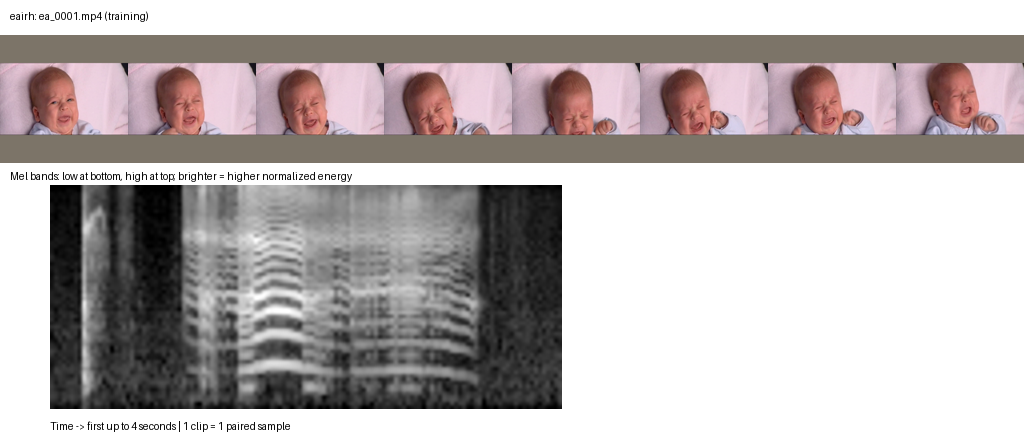

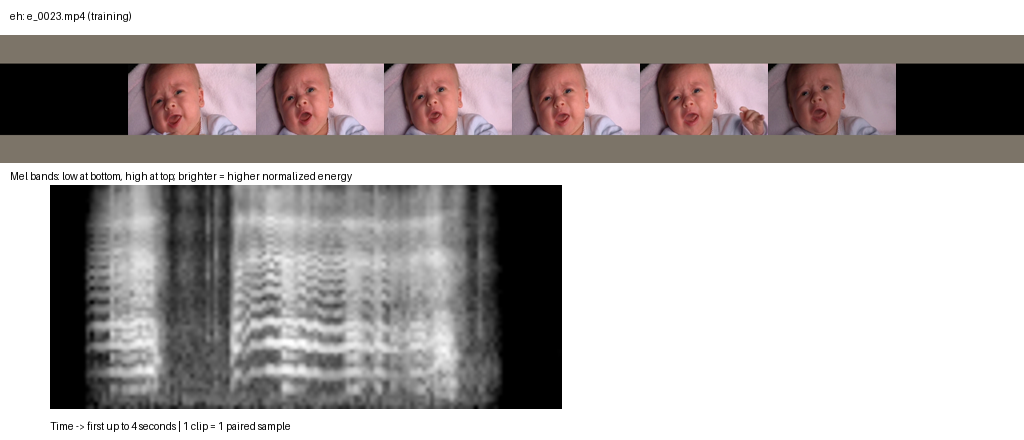

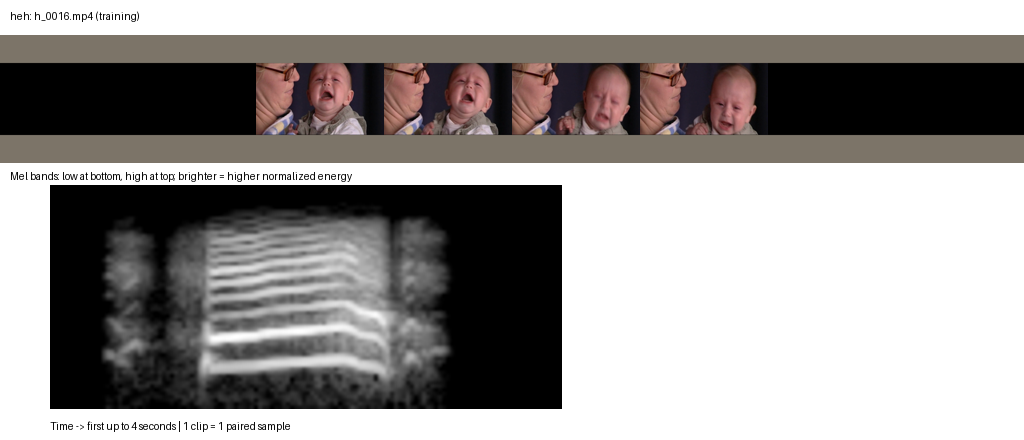

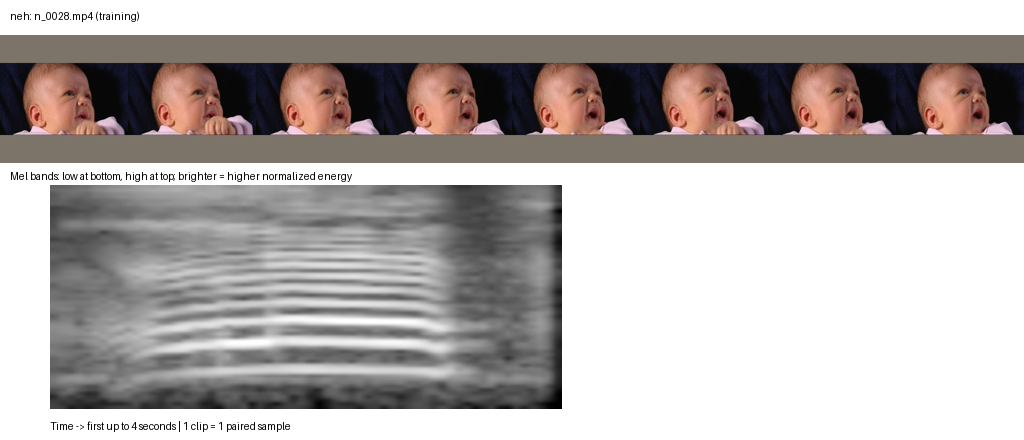

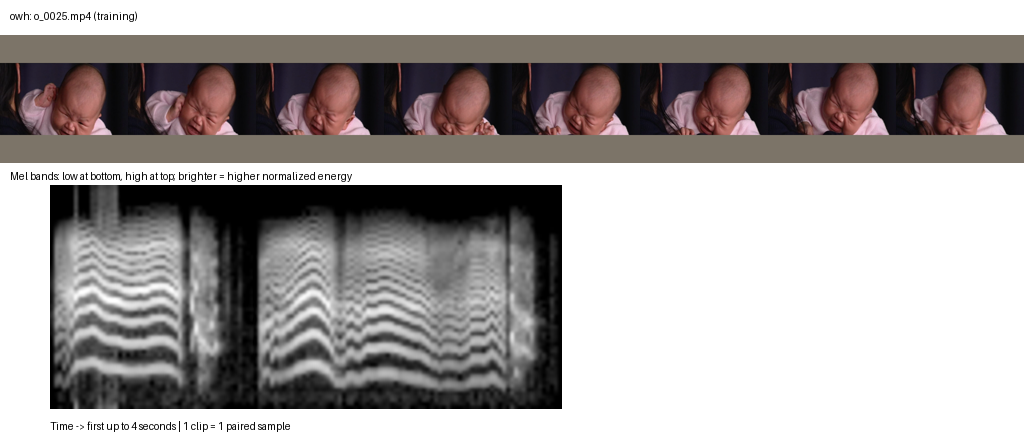

In [5]:
if REBUILD_FEATURES:
    if not shutil.which('ffmpeg') or not shutil.which('ffprobe'):
        raise RuntimeError('Install FFmpeg and ffprobe before rebuilding features')
    prepare(SimpleNamespace(data=str(ROOT), output=str(FEATURE_DIR), seed=SEED,
                            backbone='resnet18', video_preprocess='aspect_border_v1'))
data = torch.load(FEATURE_DIR/'features.pt', weights_only=True)
assert data['classes'] == list(MEANINGS)
assert data['backbone'] == 'resnet18' and data['video_preprocess'] == 'aspect_border_v1'
assert [(r['path'],r['split']) for r in data['rows']] == [(r['path'],r['split']) for r in manifest['samples']]
print('Audio:', tuple(data['mel'].shape), 'Video:', tuple(data['video'].shape))
print('Mask:', tuple(data['frame_mask'].shape))
for preview in sorted((FEATURE_DIR/'previews').glob('*.png')):
    display(NotebookImage(filename=str(preview)))

## 4. Intermediate fusion and optional frame attention

The small audio CNN maps the mel tensor to 128 dimensions. Video embeddings are
pooled, then projected from 512 to 128 dimensions. Concatenation gives a 256-D
representation, followed by dropout 0.4 and a five-class linear classifier.

Mean pooling weights valid frames equally. Attention uses LayerNorm, a 32-unit
tanh scorer, and masked softmax to learn frame weights. It is frame attention,
not cross-modal attention or explicit motion modeling. Padding never contributes.
The backbone stays frozen; the audio CNN, projections, classifier, and optional
attention scorer are trained.

In [6]:
class Fusion(nn.Module):
    def __init__(self, classes, mode="fusion", video_dim=512, pooling="mean", backbone="resnet18"):
        super().__init__()
        if pooling not in ("mean", "attention"):
            raise ValueError(f"Unknown pooling: {pooling}")
        self.mode, self.pooling, self.backbone = mode, pooling, backbone
        self.video_dim = video_dim
        self.audio = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
            nn.Flatten(), nn.Linear(64, 128), nn.ReLU())
        self.video = nn.Sequential(nn.LayerNorm(video_dim), nn.Linear(video_dim, 128), nn.ReLU())
        if pooling == "attention":
            self.attention = nn.Sequential(nn.LayerNorm(video_dim), nn.Linear(video_dim, 32),
                                           nn.Tanh(), nn.Linear(32, 1))
        self.head = nn.Sequential(nn.Dropout(0.4),
                                  nn.Linear(256 if mode == "fusion" else 128, classes))

    def pool_video(self, video, mask=None):
        if video.ndim == 2:
            if self.pooling == "attention":
                raise ValueError("Attention needs per-frame features; rerun prepare in a new output directory")
            return video
        if video.ndim != 3:
            raise ValueError("Expected batch x frames x feature_dim")
        if mask is None:
            mask = torch.ones(video.shape[:2], dtype=torch.bool, device=video.device)
        if mask.shape != video.shape[:2] or not mask.any(1).all():
            raise ValueError("Every sample needs at least one valid frame")
        if self.pooling == "attention":
            scores = self.attention(video).squeeze(-1).masked_fill(~mask, -torch.inf)
            weights = scores.softmax(1)
        else:
            weights = mask.float() / mask.sum(1, keepdim=True)
        return (video * weights.unsqueeze(-1)).sum(1)

    def forward(self, mel, video, mask=None):
        if self.mode == "audio":
            features = self.audio(mel)
        elif self.mode == "video":
            features = self.video(self.pool_video(video, mask))
        else:
            features = torch.cat([self.audio(mel), self.video(self.pool_video(video, mask))], dim=1)
        return self.head(features)


def loader(data, split, shuffle=False):
    ids = [i for i, row in enumerate(data["rows"]) if row["split"] == split]
    if not ids:
        raise ValueError(f"No {split} samples")
    tensors = [data["mel"][ids], data["video"][ids], data["labels"][ids]]
    if "frame_mask" in data:
        tensors.append(data["frame_mask"][ids])
    return DataLoader(TensorDataset(*tensors), batch_size=16, shuffle=shuffle)

## 5. Metrics, optimization, and checkpoint selection

AdamW uses learning rate 0.001 and weight decay 0.01, with batch size 16.
Both models use seed 42, a maximum of 100 epochs, and patience 10. A strictly
higher validation macro F1 saves best.pt; ties keep the earliest checkpoint.
Training metrics are measured after each epoch in evaluation mode.

Accuracy is correct predictions divided by samples. Precision measures how often
a predicted class is correct; recall measures how much of an actual class is found.
Per-class F1 is their harmonic mean; macro F1 averages classes equally. Confusion
matrix rows are actual classes and columns are predictions. No test metrics enter
early stopping, checkpoint selection, or the mean-versus-attention decision.

In [7]:
def save_curves(history, path):
    """Render new or legacy history without inventing missing training metrics."""
    if not history:
        raise ValueError("History is empty")
    canvas = Image.new("RGB", (1080, 380), "white")
    draw = ImageDraw.Draw(canvas)
    epochs = [r["epoch"] for r in history]
    best = max(history, key=lambda r: r["macro_f1"])
    for panel, metric in enumerate(("loss", "accuracy", "macro_f1")):
        x, y, width, height = panel * 360 + 45, 55, 285, 240
        draw.text((x, 12), metric.replace("_", " "), fill="black")
        draw.rectangle((x, y, x + width, y + height), outline="black")
        series = [("Training (eval)", "#bb4433", [(r["epoch"], r["train"][metric]) for r in history if metric in r.get("train", {})]),
                  ("Validation", "#2266bb", [(r["epoch"], r[metric]) for r in history if metric in r])]
        values = [v for _, _, points in series for _, v in points]
        maximum = max(max(values, default=1), 1e-6) * 1.05 if metric == "loss" else 1
        for tick in (0, 0.5, 1):
            draw.text((x - 38, y + height * (1-tick)), f"{maximum*tick:.2f}", fill="black")
        for index, (label, color, points) in enumerate(series):
            draw.text((x, 315 + 16 * index), label if points else label + ": unavailable", fill=color)
            coords = [(x + (e-min(epochs))/max(1,max(epochs)-min(epochs))*width,
                       y + height * (1-v/maximum)) for e, v in points]
            if len(coords) > 1:
                draw.line(coords, fill=color, width=2)
            for px, py in coords:
                draw.ellipse((px-2, py-2, px+2, py+2), fill=color)
        draw.text((x, 299), f"Epoch {min(epochs)}", fill="black")
        draw.text((x+210, 299), str(max(epochs)), fill="black")
    draw.text((45, 360), f"Best validation macro F1: epoch {best['epoch']} ({best['macro_f1']:.4f}); first epoch wins ties", fill="black")
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    canvas.save(path)


@torch.inference_mode()
def evaluate(model, batches, classes):
    model.eval()
    matrix = torch.zeros(len(classes), len(classes), dtype=torch.int64)
    loss_sum = 0.
    for mel, video, labels, *mask in batches:
        logits = model(mel, video, *mask)
        loss_sum += nn.functional.cross_entropy(logits, labels, reduction="sum").item()
        predictions = logits.argmax(1)
        for actual, predicted in zip(labels, predictions):
            matrix[actual, predicted] += 1
    tp = matrix.diag().float()
    recall = tp / matrix.sum(1).clamp_min(1)
    precision = tp / matrix.sum(0).clamp_min(1)
    f1 = 2 * precision * recall / (precision + recall).clamp_min(1e-8)
    if matrix.sum() == 0:
        raise ValueError("Cannot evaluate an empty dataset")
    return dict(loss=loss_sum / matrix.sum().item(),
                accuracy=(tp.sum() / matrix.sum()).item(), macro_f1=f1.mean().item(),
                precision=dict(zip(classes, precision.tolist())),
                f1=dict(zip(classes, f1.tolist())),
                support=dict(zip(classes, matrix.sum(1).tolist())),
                recall=dict(zip(classes, recall.tolist())), confusion_matrix=matrix.tolist(),
                class_order=classes)


def early_stop(history, patience):
    """Stop after patience epochs without a strictly higher validation macro F1."""
    if patience < 0:
        raise ValueError("patience must be non-negative")
    if patience == 0 or not history:
        return False
    best = max(history, key=lambda row: row["macro_f1"])
    return history[-1]["epoch"] - best["epoch"] >= patience


def train(args):
    torch.manual_seed(args.seed)
    data = torch.load(args.features, weights_only=True)
    if args.pooling == "attention" and data["video"].ndim != 3:
        raise ValueError("Attention needs per-frame features; rerun prepare in a new output directory")
    model = Fusion(len(data["classes"]), args.mode, data["video"].shape[-1],
                   args.pooling, data.get("backbone", "resnet18"))
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
    training, validation = loader(data, "train", True), loader(data, "val")
    training_eval = loader(data, "train")
    best, history = -1., []
    out = Path(args.output)
    out.mkdir(parents=True, exist_ok=True)
    for epoch in range(args.epochs):
        model.train()
        for mel, video, labels, *mask in training:
            optimizer.zero_grad()
            loss = nn.functional.cross_entropy(model(mel, video, *mask), labels)
            loss.backward()
            optimizer.step()
        # Reporting must not advance the RNG used by training shuffles/dropout.
        with torch.random.fork_rng(devices=[]):
            train_metrics = evaluate(model, training_eval, data["classes"])
        metrics = evaluate(model, validation, data["classes"])
        history.append(dict(epoch=epoch + 1, train=train_metrics, **metrics))
        print(f"Epoch {epoch + 1}: validation macro F1={metrics['macro_f1']:.3f}", flush=True)
        if metrics["macro_f1"] > best:
            best = metrics["macro_f1"]
            torch.save(dict(state=model.state_dict(), classes=data["classes"],
                            video_preprocess=data.get("video_preprocess", "legacy_stretch"),
                            backbone=model.backbone, video_dim=model.video_dim, pooling=model.pooling,
                            mode=args.mode, seed=args.seed, epoch=epoch + 1), out / "best.pt")
        if early_stop(history, args.patience):
            print(f"Early stopping at epoch {epoch + 1}: no validation macro F1 improvement for {args.patience} epochs.", flush=True)
            break
    (out / "history.json").write_text(json.dumps(history, indent=2))
    best_row = max(history, key=lambda row: row["macro_f1"])
    summary = dict(best_epoch=best_row["epoch"], selection_metric="validation_macro_f1",
                   video_preprocess=data.get("video_preprocess", "legacy_stretch"),
                   epochs_requested=args.epochs, epochs_completed=len(history),
                   patience=args.patience, stopped_early=len(history) < args.epochs,
                   stop_reason="patience_exhausted" if early_stop(history, args.patience) else "epoch_limit",
                   backbone=model.backbone, pooling=model.pooling,
                   tie_break="earliest_epoch", mode=args.mode, classes=data["classes"],
                   seed=args.seed, features=str(args.features),
                   sample_counts={s: sum(r["split"] == s for r in data["rows"]) for s in ("train", "val", "test")},
                   validation_metrics={k: v for k, v in best_row.items() if k not in ("epoch", "train")})
    (out / "training_summary.json").write_text(json.dumps(summary, indent=2))
    (out / "validation_metrics.json").write_text(json.dumps(summary["validation_metrics"], indent=2))
    save_curves(history, out / "training_curves.png")


def restore(path):
    checkpoint = torch.load(path, weights_only=True)
    model = Fusion(len(checkpoint["classes"]), checkpoint["mode"],
                   checkpoint.get("video_dim", 512), checkpoint.get("pooling", "mean"),
                   checkpoint.get("backbone", "resnet18"))
    model.load_state_dict(checkpoint["state"])
    model.video_preprocess = checkpoint.get("video_preprocess", "legacy_stretch")
    return model.eval(), checkpoint["classes"]

In [8]:
if RUN_TRAINING:
    for pooling in ('mean','attention'):
        target = RUN_ROOT / pooling
        if target.exists():
            raise FileExistsError(f'Choose a fresh RUN_ROOT rather than overwriting {target}')
    for pooling in ('mean','attention'):
        train(SimpleNamespace(features=str(FEATURE_DIR/'features.pt'), output=str(RUN_ROOT/pooling),
                              mode='fusion', pooling=pooling, epochs=EPOCHS, patience=PATIENCE, seed=SEED))
else:
    print('Using supplied trained checkpoints; no training started.')

Using supplied trained checkpoints; no training started.


## 6. Compare validation results first

Recorded mean: best epoch 43, stopped at 53, accuracy 22/26 (84.62%), macro F1
0.86476. Recorded attention: best epoch 40, stopped at 50, accuracy 21/26 (80.77%),
macro F1 0.78029. Mean was selected using validation, before test evaluation.
With only two eairh validation samples, its 2/2 versus 1/2 result is highly uncertain.

mean best epoch 43 accuracy 0.8461538553237915 macro F1 0.8647619485855103


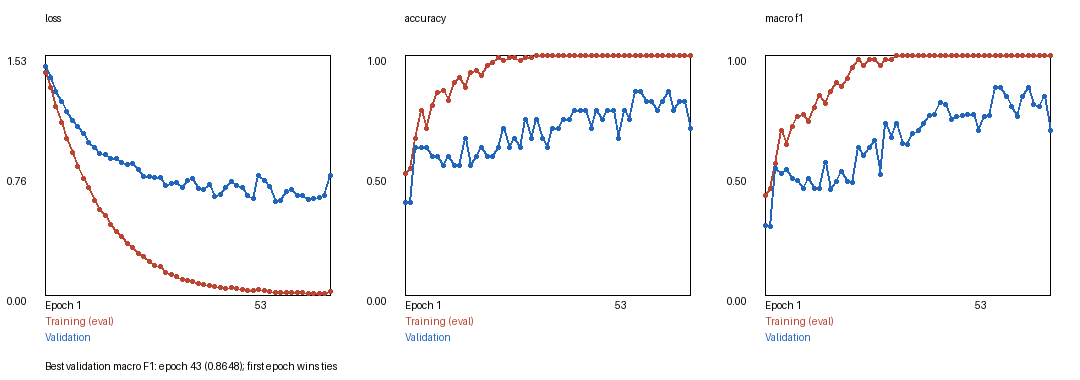

attention best epoch 40 accuracy 0.807692289352417 macro F1 0.780286431312561


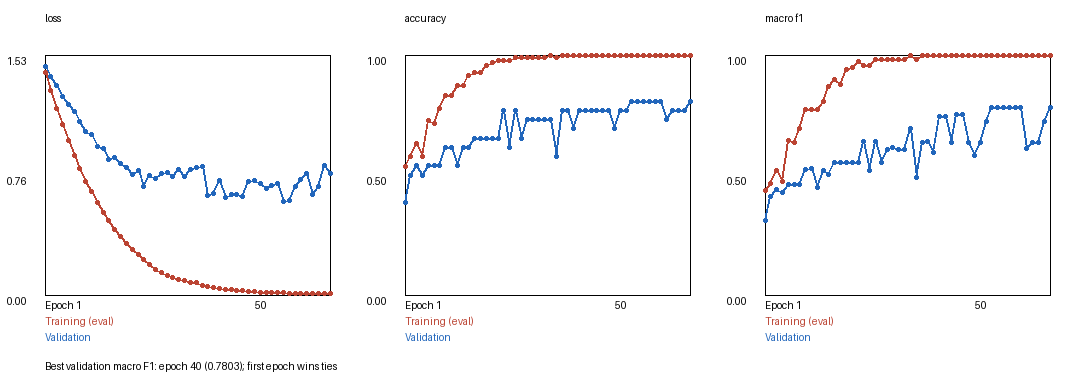

Selected using validation only: mean


In [9]:
summaries = {mode: json.loads((MODEL_ROOT/mode/'training_summary.json').read_text())
             for mode in ('mean','attention')}
for mode, summary in summaries.items():
    metric = summary['validation_metrics']
    print(mode, 'best epoch', summary['best_epoch'], 'accuracy', metric['accuracy'], 'macro F1', metric['macro_f1'])
    display(NotebookImage(filename=str(MODEL_ROOT/mode/'training_curves.png')))
SELECTED = max(summaries, key=lambda mode: summaries[mode]['validation_metrics']['macro_f1'])
print('Selected using validation only:', SELECTED)

## 7. Evaluate the selected model once

The supplied mean model's recorded test accuracy is **26/32 = 81.25%**, macro F1
**0.75780**. Recall: eairh 1/4, eh 7/7, heh 7/7, neh 6/7, owh 5/7.
The overall score hides weak eairh recall. Attention has no test score because it
was not the validation-selected model. Do not evaluate alternatives on test to
pick a winner, or tune the model to these known test results.

By default the cell displays saved metrics. Enable RUN_TEST_EVALUATION only for
an intentional evaluation after all training and selection decisions are fixed.
The earlier 85.7% four-class/28-clip result is not directly comparable.

In [10]:
test_path = MODEL_ROOT/SELECTED/'test_metrics.json'
if RUN_TEST_EVALUATION:
    if test_path.exists():
        raise FileExistsError('Test metrics already exist; review them instead of overwriting.')
    model, classes = restore(MODEL_ROOT/SELECTED/'best.pt')
    assert classes == data['classes']
    assert model.backbone == data['backbone'] and model.video_preprocess == data['video_preprocess']
    metrics = evaluate(model, loader(data, 'test'), classes)
    test_path.write_text(json.dumps(metrics, indent=2))
if test_path.exists():
    test_metrics = json.loads(test_path.read_text())
    display(test_metrics)
else:
    test_metrics = None
    print('No test evaluation performed for this run.')

{'loss': 0.5610826015472412,
 'accuracy': 0.8125,
 'macro_f1': 0.7578011751174927,
 'precision': {'eairh': 1.0,
  'eh': 0.7777777910232544,
  'heh': 0.699999988079071,
  'neh': 0.8571428656578064,
  'owh': 1.0},
 'f1': {'eairh': 0.4000000059604645,
  'eh': 0.875,
  'heh': 0.8235293626785278,
  'neh': 0.8571428656578064,
  'owh': 0.8333333730697632},
 'support': {'eairh': 4, 'eh': 7, 'heh': 7, 'neh': 7, 'owh': 7},
 'recall': {'eairh': 0.25,
  'eh': 1.0,
  'heh': 1.0,
  'neh': 0.8571428656578064,
  'owh': 0.7142857313156128},
 'confusion_matrix': [[1, 0, 2, 1, 0],
  [0, 7, 0, 0, 0],
  [0, 0, 7, 0, 0],
  [0, 1, 0, 6, 0],
  [0, 1, 1, 0, 5]],
 'class_order': ['eairh', 'eh', 'heh', 'neh', 'owh']}

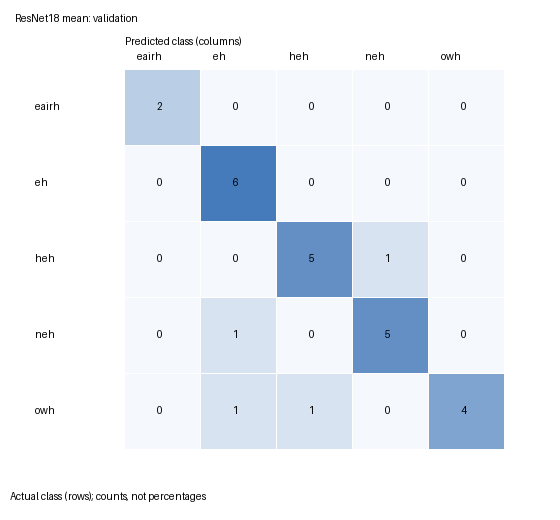

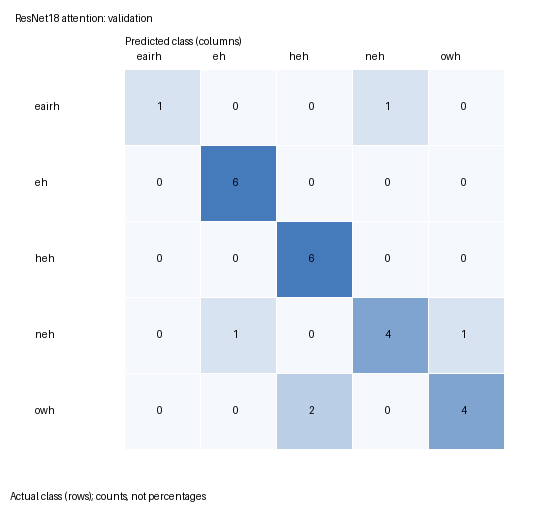

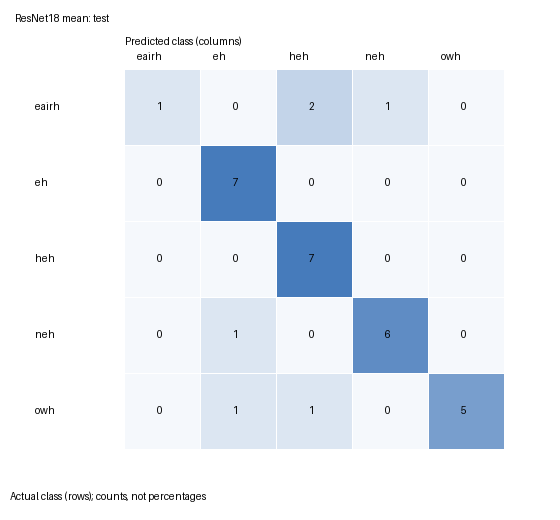

In [11]:
def confusion_plot(metrics, path, title):
    labels, matrix = metrics['class_order'], np.array(metrics['confusion_matrix'])
    size, left, top = 76, 125, 70
    canvas = Image.new('RGB', (560, 520), 'white')
    draw = ImageDraw.Draw(canvas)
    draw.text((15,12), title, fill='black')
    draw.text((left,35), 'Predicted class (columns)', fill='black')
    draw.text((10,490), 'Actual class (rows); counts, not percentages', fill='black')
    for i,name in enumerate(labels):
        draw.text((left+i*size+12,top-20), name, fill='black')
        draw.text((35,top+i*size+30), name, fill='black')
        for j in range(len(labels)):
            value = int(matrix[i,j]); strength = value/max(1,int(matrix.max()))
            color = (int(245-175*strength),int(248-125*strength),int(252-65*strength))
            x,y = left+j*size,top+i*size
            draw.rectangle((x,y,x+size-2,y+size-2),fill=color)
            draw.text((x+32,y+30),str(value),fill='black')
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    canvas.save(path)

for mode, summary in summaries.items():
    plot = MODEL_ROOT/mode/'validation_confusion.png'
    confusion_plot(summary['validation_metrics'], plot, f'ResNet18 {mode}: validation')
    display(NotebookImage(filename=str(plot)))
if test_metrics is not None:
    plot = MODEL_ROOT/SELECTED/'test_confusion.png'
    confusion_plot(test_metrics, plot, f'ResNet18 {SELECTED}: test')
    display(NotebookImage(filename=str(plot)))

## 8. Optional prediction on a new video

The checkpoint determines the preprocessing and pooling. The frozen ImageNet
backbone is loaded separately; best.pt contains the trained fusion head, not the
ResNet weights. Scores are uncalibrated and must not guide medical decisions.

In [12]:
PREDICT_VIDEO = None  # Example: ROOT / 'your_new_video.mp4'
if PREDICT_VIDEO is not None:
    model, classes = restore(MODEL_ROOT/SELECTED/'best.pt')
    mel, video = Extractor(model.backbone, frame_features=True,
                           video_preprocess=model.video_preprocess)(PREDICT_VIDEO)
    with torch.inference_mode():
        scores = model(mel[None], video[None]).softmax(1)[0]
    display(dict(zip(classes,scores.tolist())))

## 9. Interpretation and reproducibility limits

This is a small academic prototype, not production or medical-grade validation.
One error changes test accuracy by 3.125 percentage points. There is no external
validation on new babies, phones, or environments. Within-DVD overlap can inflate
scores. Removing clips and changing the split confounds comparison to earlier runs;
the result does not establish that the removed labels were wrong.

The split generator's shared RNG means changing class membership can also alter
other-class validation assignments. The included manifest and hash checks freeze
the exact experiment. Existing results remain in results/; new runs go in runs/.
Backbone weights require internet on first use, and FFmpeg/version differences can
change features slightly. Use the recorded CPU environment for closest reproduction.

Technical references: [ResNet18](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.resnet18.html),
[MelSpectrogram](https://docs.pytorch.org/audio/stable/generated/torchaudio.transforms.MelSpectrogram.html).
No redistribution license for source video is asserted by this package.